# Master in Applied Artificial Intelligence

## Course: *Computer Vision for Images and Video*

### **4.2 Google Colab** - Image enhancement algorithms using morphological operations

---

**Institution:** Tecnológico de Monterrey

**Instructors:** Gilberto Ochoa Ruiz, Daniel Flores Araiza, Ma. del Refugio Meléndez Alfaro

**Authors (Team 38):** 

|  FULL NAME                      |     STUDENT ID    | 
| :--------------------------:    |:-----------------:|
| Alejandro Díaz Villagómez       |  A01276769        | 
| Carlos Rodrigo Sánchez Sierra   |  A01424454        | 
| Emiliano Saucedo Arriola        |  A01659258        | 

**Date:** October 5th, 2025

---

# 4. Morphological Operations

## Table of Contents
1. [Libraries](#libraries)
2. [Erosion](#erosion)
3. [Dilation](#dilation)
4. [Opening](#opening)
5. [Closing](#closing)
6. [Morphological Gradient](#gradient)
7. [Morphological Hats](#hats)
   1. [Top or White Hat](#top)
   1. [Black Hat](#black)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread("data/image.jpg")
img1 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2 = cv2.imread("data/image.jpg",0)

(681, 1024, 3) (681, 1024, 3) (681, 1024)


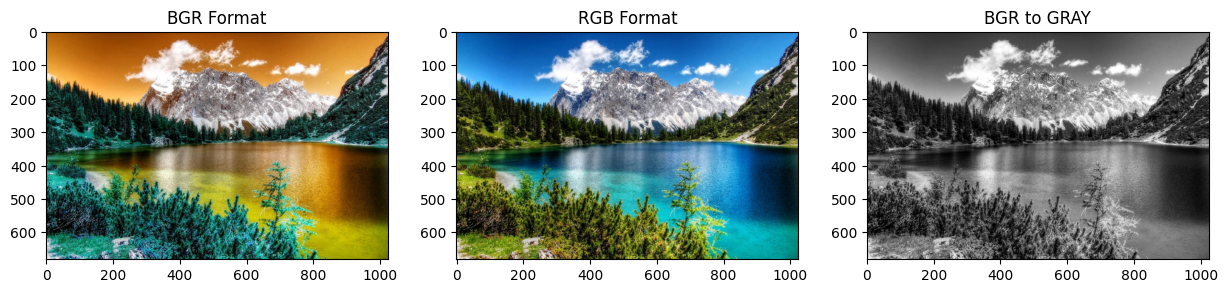

In [3]:
#function to see image
def imgshow(img=img,img1=img1,img2=img2, rows=1,columns=3):
    print(img.shape,img1.shape,img2.shape)
    fig = plt.figure(figsize=(15,8))
    #adds a subplot at 1st position
    fig.add_subplot(rows,columns,1)
    plt.title('BGR Format')
    plt.imshow(img)

    #adds a subplot at 2nd position
    fig.add_subplot(rows,columns,2)
    plt.title('RGB Format')
    plt.imshow(img1)

    #adds a subplot at 3rd position
    fig.add_subplot(rows,columns, 3)
    plt.title('BGR to GRAY')
    plt.imshow(img2,cmap="gray")
    plt.show()
    
imgshow(img=img,img1=img1,img2=img2, rows=1,columns=3)

## Erosion <a class="anchor" id="erosion" ></a>

Erosin primarily involves eroding(thinning) outer surface(foreground) of image
- Tt is suggested to have foreground as white

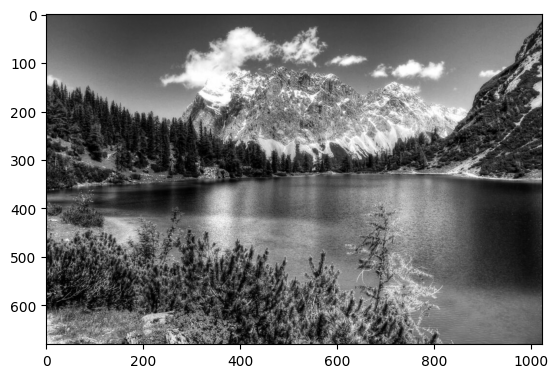

In [4]:
BGR2GRAY = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(BGR2GRAY,cmap="gray")
plt.show()

Eroding boundy of image upto 3 level

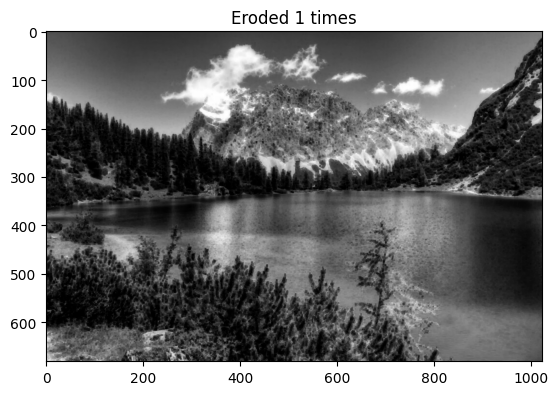

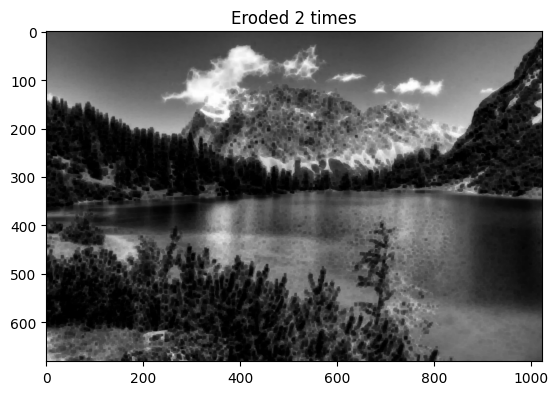

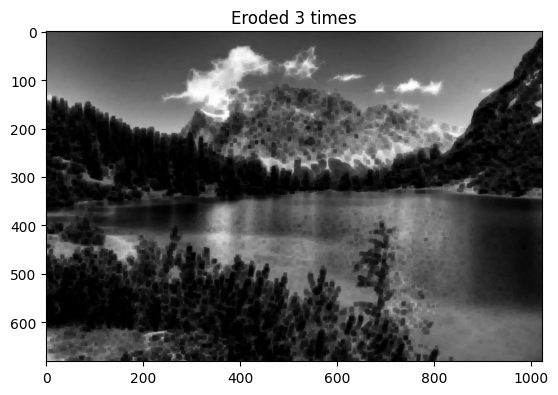

In [5]:
def plt_imshow(title, image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.title(title)
    plt.grid(False)
    plt.show()
    
for i in range(0,3):
    eroded = cv2.erode(BGR2GRAY.copy(), None, iterations=i+1)
    plt_imshow("Eroded {} times".format(i+1), eroded)

### Binarize Image

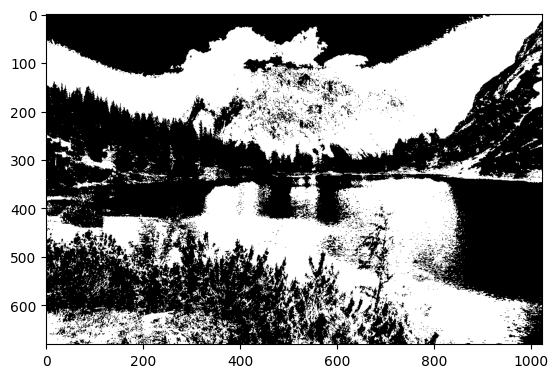

In [6]:
binr = cv2.threshold(BGR2GRAY, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
image = cv2.cvtColor(binr, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

### We can Invert Image to keep foreground in white

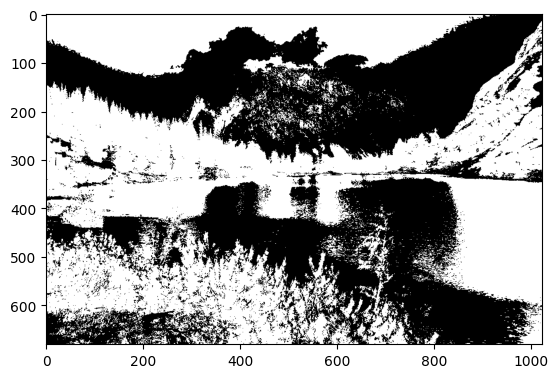

In [7]:
invert = cv2.bitwise_not(binr)
image = cv2.cvtColor(invert, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

Then, we can define a kernel of $5 \times 5$ to use in erosion

In [8]:
kernel = np.ones((5,5), np.uint8) #check for 3*3 or 7*7 kernel size too
print(kernel)

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


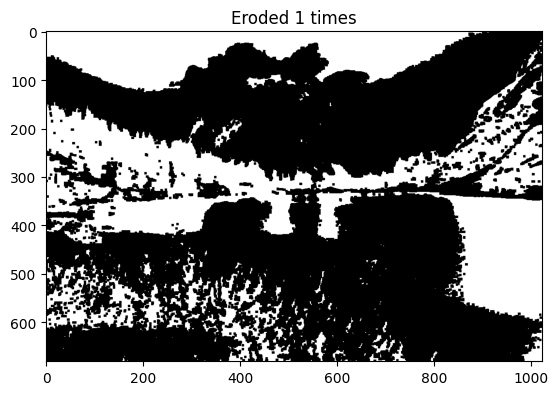

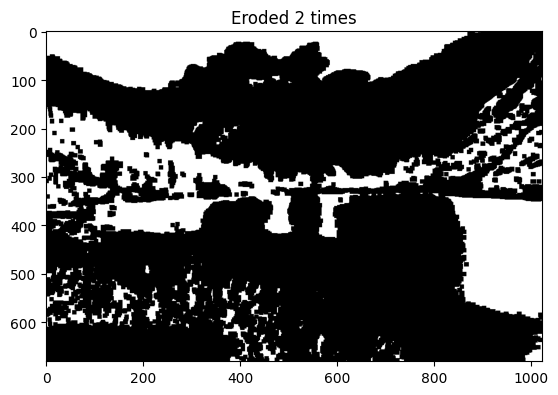

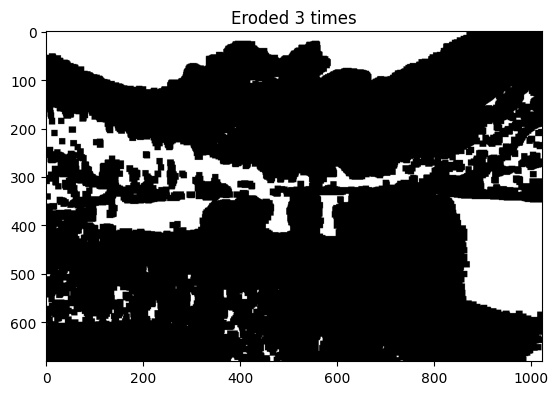

In [9]:
for i in range(0,3):
    eroded = cv2.erode(invert.copy(),kernel=kernel, iterations=i+1)
    plt_imshow("Eroded {} times".format(i+1), eroded)

## Dilation <a class="anchor" id="dilation" ></a>

Involves dilating outer surface (foreground) of image
- For joining broken parts of an image together

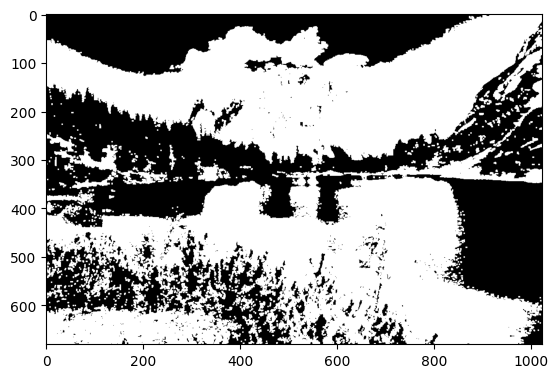

In [10]:
#binarize image
binr = cv2.threshold(BGR2GRAY,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
kernel = np.ones((3,3),np.uint8)
invert = cv2.bitwise_not(binr)

#dilate image
dilation = cv2.dilate(binr, kernel, iterations=1)
 
plt.imshow(dilation, cmap='gray')
plt.show()

We can apply series of dilations on inverted image using no kernel


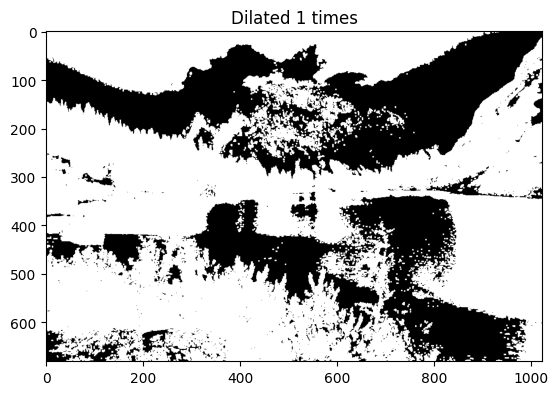

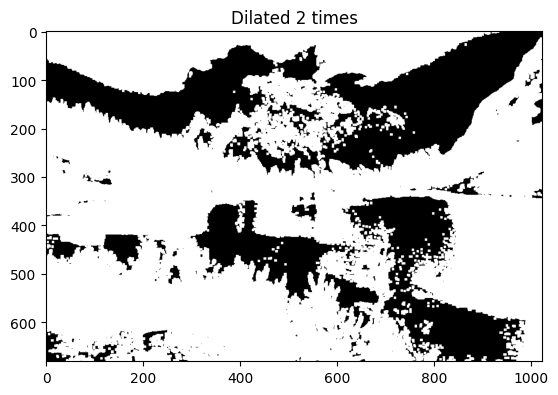

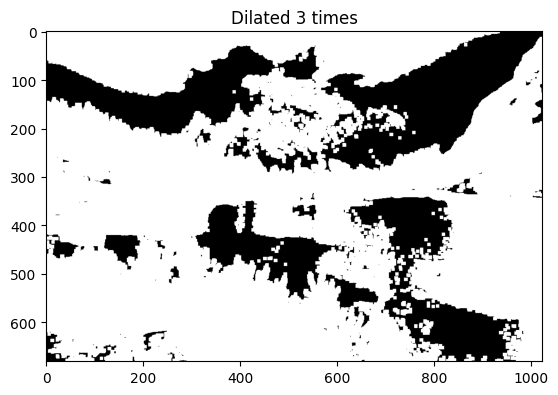

In [11]:
for i in range(0,3):
    dilated = cv2.dilate(invert.copy(),None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),dilated)

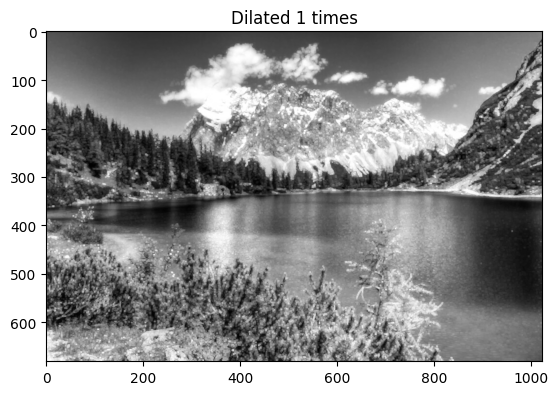

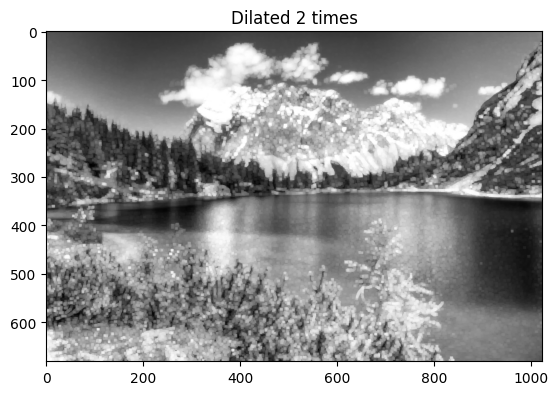

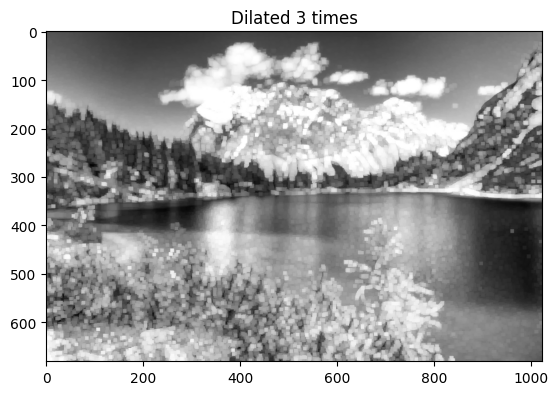

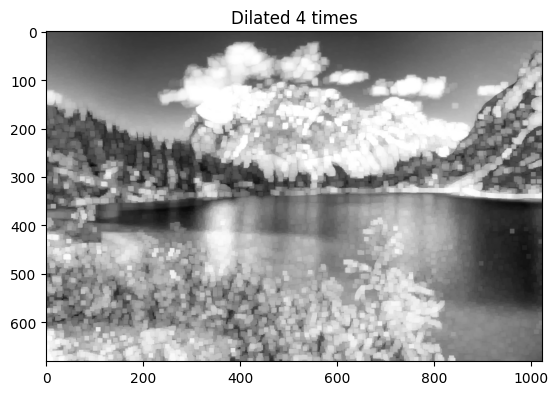

In [12]:
for i in range(0,4):
    dilated = cv2.dilate(BGR2GRAY.copy(),None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),dilated)

## Opening <a class="anchor" id="opening" ></a>

Erosion followed by dilation in outer surface (foreground) of image
- Generally used to remove noise (small blobs) in image


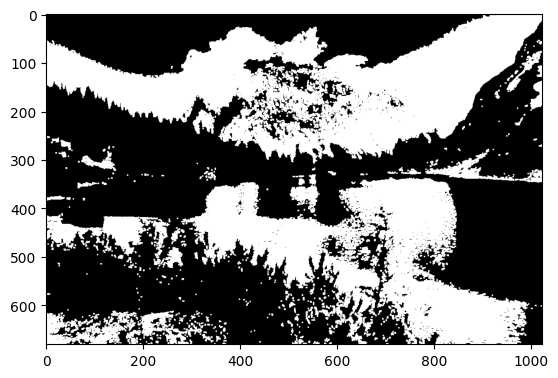

In [13]:
#opening image
opening = cv2.morphologyEx(binr,cv2.MORPH_OPEN,kernel,iterations=1)

#print output
plt.imshow(opening, cmap='gray')
plt.show()

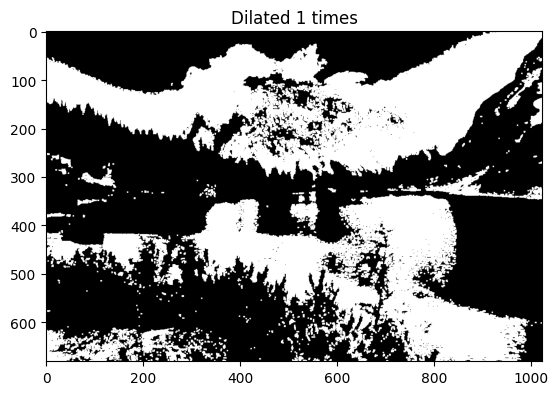

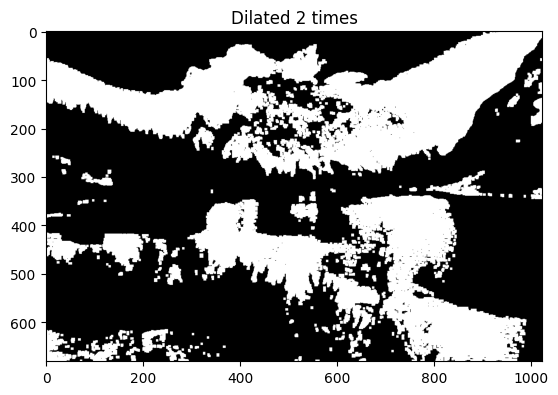

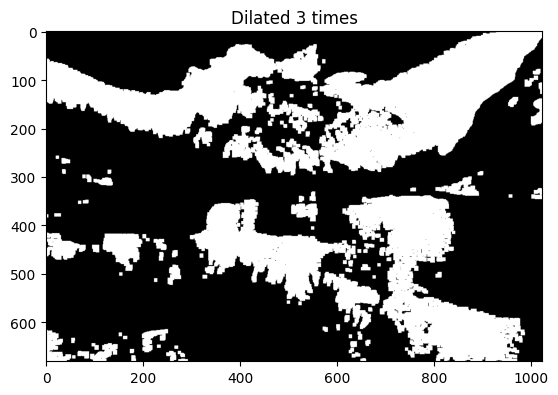

In [14]:
for i in range(0,3):
    opening = cv2.morphologyEx(binr.copy(),cv2.MORPH_OPEN,None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),opening)
    plt.show()

## Closing <a class="anchor" id="closing" ></a>

Dilation followed by erosion in outer surface (foreground) of image
- Generally used to close holes inside of objects or for connecting components together

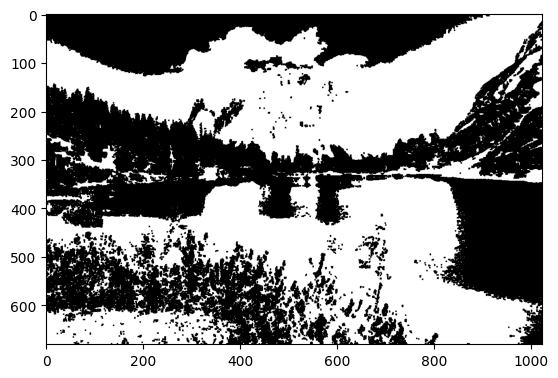

In [15]:
#closing image
closing = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel, iterations=1)
 
#print output
plt.imshow(closing,cmap='gray')
plt.show()

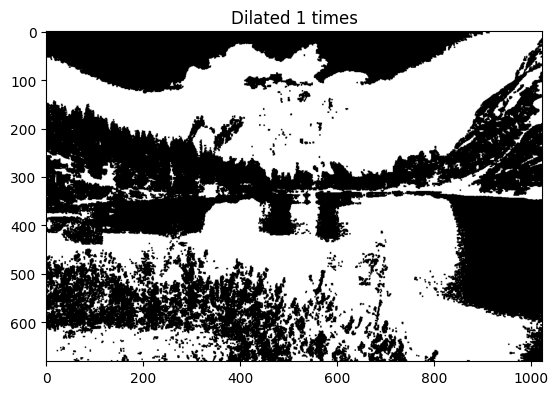

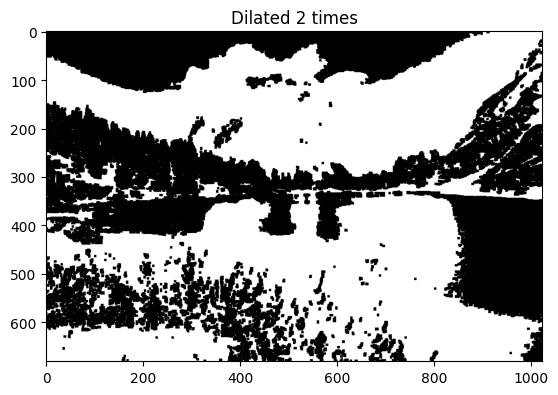

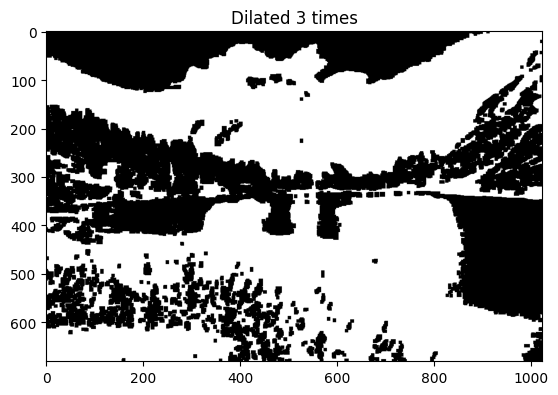

In [16]:
for i in range(0,3):
    closing = cv2.morphologyEx(binr.copy(),cv2.MORPH_CLOSE,None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),closing)
    plt.show()

Iterating with different kernels

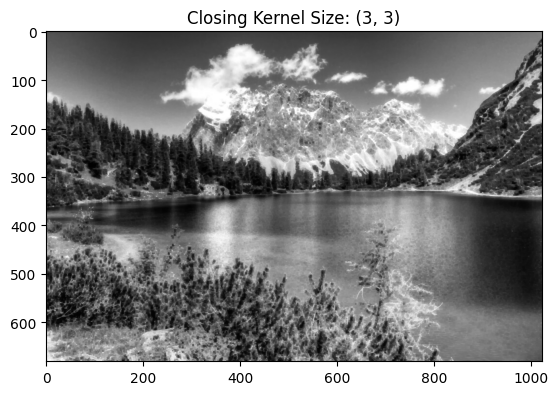

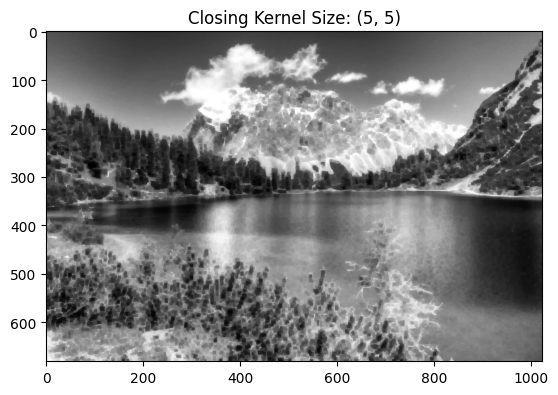

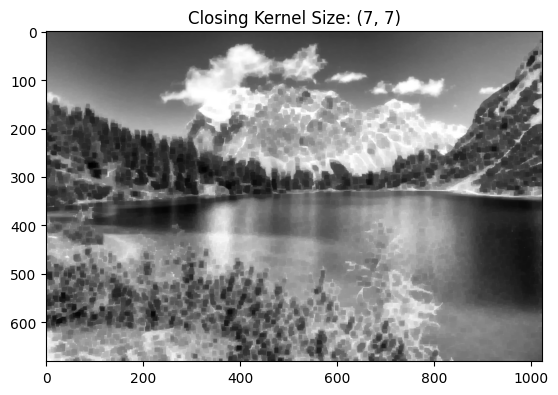

In [17]:
kernelSizes = [(3,3), (5,5), (7,7)]
BGR2GRAY = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

for kernelSize in kernelSizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernelSize)
    closing = cv2.morphologyEx(BGR2GRAY, cv2.MORPH_CLOSE, kernel)
    plt_imshow("Closing Kernel Size: ({}, {})".format(kernelSize[0], kernelSize[1]), closing)

## Morphological Gradient <a class="anchor" id="gradient" ></a>

It first applies erosion and dilation individually on image and then computes difference between eroded and dilated image

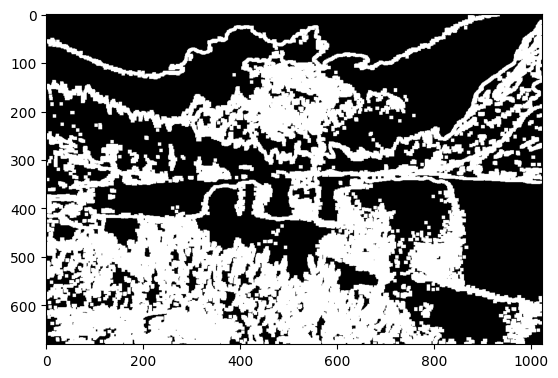

In [18]:
# use morph gradient
morph_gradient = cv2.morphologyEx(invert,cv2.MORPH_GRADIENT,kernel)
 
#print output
plt.imshow(morph_gradient, cmap='gray')
plt.show()

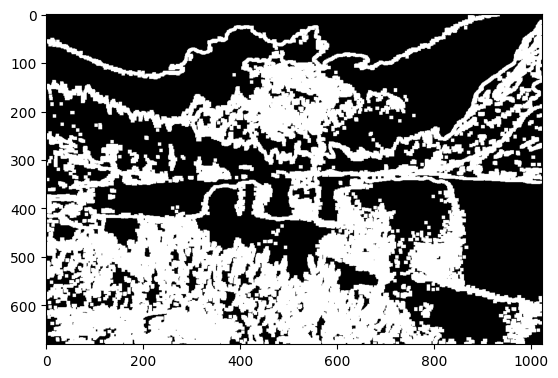

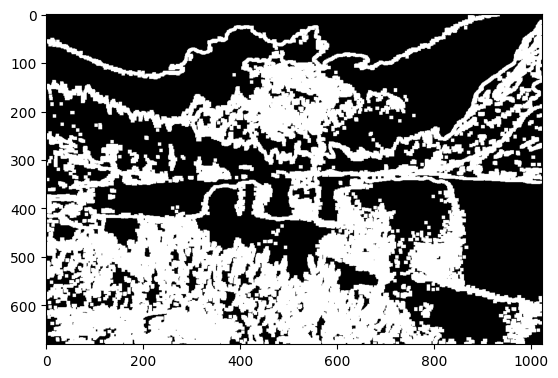

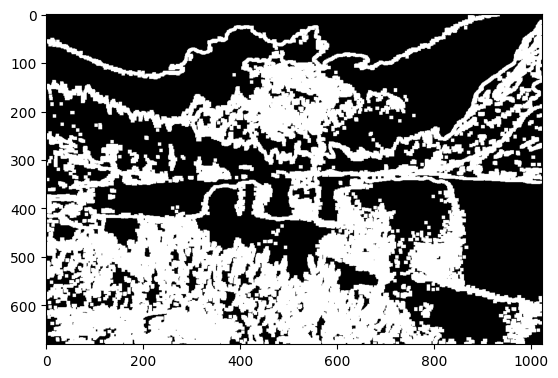

In [19]:
for i in range(0,3): 
    # use morph gradient
    morph_gradient = cv2.morphologyEx(invert,cv2.MORPH_GRADIENT,kernel+i)
    #print output
    plt.imshow(morph_gradient, cmap='gray')
    plt.show()

Iterating with different kernels

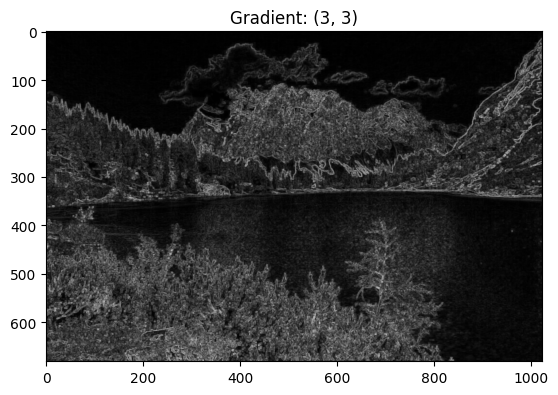

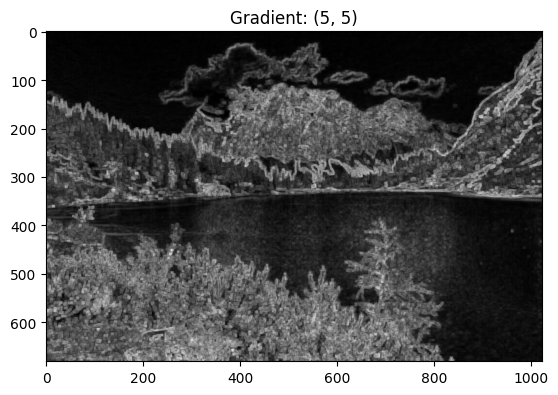

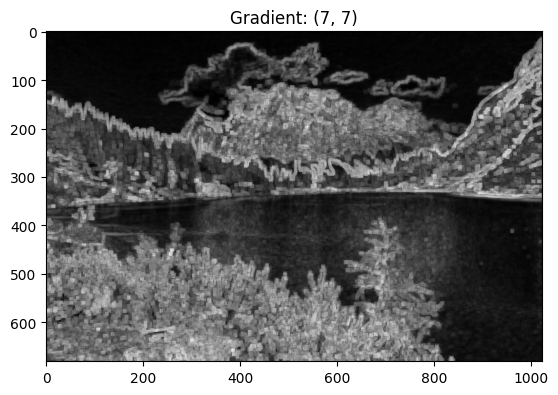

In [20]:
kernelSizes = [(3,3), (5,5), (7,7)]
BGR2GRAY = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

for kernelSize in kernelSizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernelSize)
    gradient = cv2.morphologyEx(BGR2GRAY, cv2.MORPH_GRADIENT, kernel)
    plt_imshow("Gradient: ({}, {})".format(
        kernelSize[0], kernelSize[1]), gradient)

## Morphological Hats <a class="anchor" id="hats" ></a>

1. Top or White Hat
2. Black hat

### Top or White Hat <a class="anchor" id="top" ></a>

It is the difference between original (grayscale/single channel) input image and opening image

- Finds light(bright) regions of an image on dark background


In [21]:
#construct a kernel (13x5)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(13,5))
kernel

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=uint8)

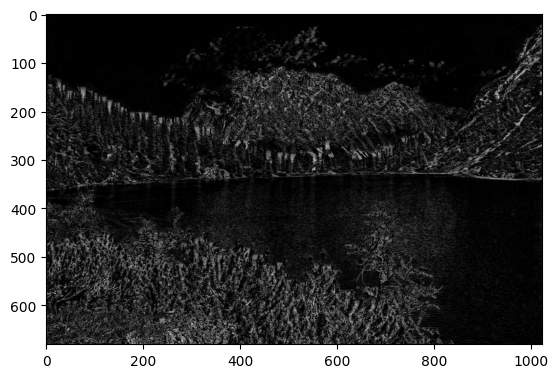

In [22]:
tophat = cv2.morphologyEx(BGR2GRAY, cv2.MORPH_TOPHAT, kernel)

plt.imshow(tophat, cmap='gray')
plt.show()

### Black Hat <a class="anchor" id="black" ></a>

Output is a difference between input image & opened image
- Finds dark regions on a light background


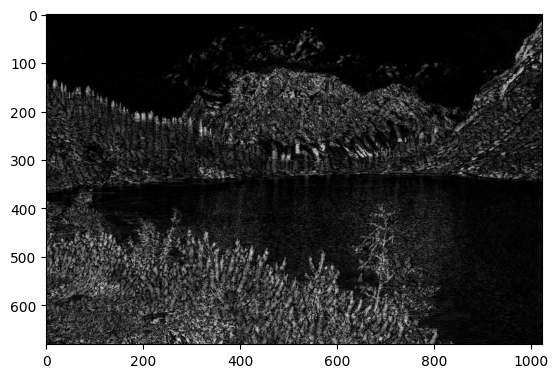

In [23]:
blackhat = cv2.morphologyEx(BGR2GRAY,cv2.MORPH_BLACKHAT,kernel)

plt.imshow(blackhat, cmap='gray')
plt.show()

# > Solution

## 1 - Morphological Erosion in Image Processing

**Research Background**

Morphological operations are fundamental techniques in digital image processing that analyze and process images based on their geometric structure. Among these operations, erosion is one of the most essential morphological transformations, widely used in preprocessing pipelines for object detection, noise removal, and feature extraction tasks (Gonzalez & Woods, 2018). Erosion operates by systematically shrinking or thinning foreground regions in binary or grayscale images using a structuring element.

Erosion is a morphological operation that removes pixels from object boundaries based on the fit of a structuring element (Soille, 2003). For binary images, erosion removes boundary pixels from objects, effectively shrinking them. The operation is computed by placing the structuring element at each pixel position and checking if all elements overlap with foreground pixels. For grayscale images, erosion replaces each pixel with the minimum value within the neighborhood defined by the structuring element (Burger & Burge, 2016).

**Application: Medical Image Analysis**

A significant application of erosion is in medical image analysis, specifically for cell segmentation in microscopy images. Erosion removes small noise particles and separates touching cells by shrinking them sufficiently to create gaps. This preprocessing step is crucial for automated cell counting systems used in biological research and clinical diagnostics (Gonzalez & Woods, 2018). The structuring element's size directly influences separation effectiveness, balancing between breaking connections and preserving cell integrity.

**References**

- Burger, W., & Burge, M. J. (2016). Digital image processing: An algorithmic introduction using Java (2nd ed.). Springer.

- Gonzalez, R. C., & Woods, R. E. (2018). Digital image processing (4th ed.). Pearson.

- Soille, P. (2003). Morphological image analysis: Principles and applications (2nd ed.). Springer.

In [24]:
def erode(image, kernel):
    """
    Morphological erosion operation
    Args:
        image: 2D numpy array (grayscale image)
        kernel: 2D numpy array (structuring element)
    Returns:
        Eroded image
    """
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape
    
    pad_h = ker_h // 2
    pad_w = ker_w // 2
    
    # Padding with maximum value
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), 
                    mode='constant', constant_values=255)
    
    output = np.zeros_like(image, dtype=np.float64)
    
    # Erosion: minimum value in neighborhood
    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i+ker_h, j:j+ker_w]
            output[i, j] = np.min(region[kernel == 1])
    
    return output

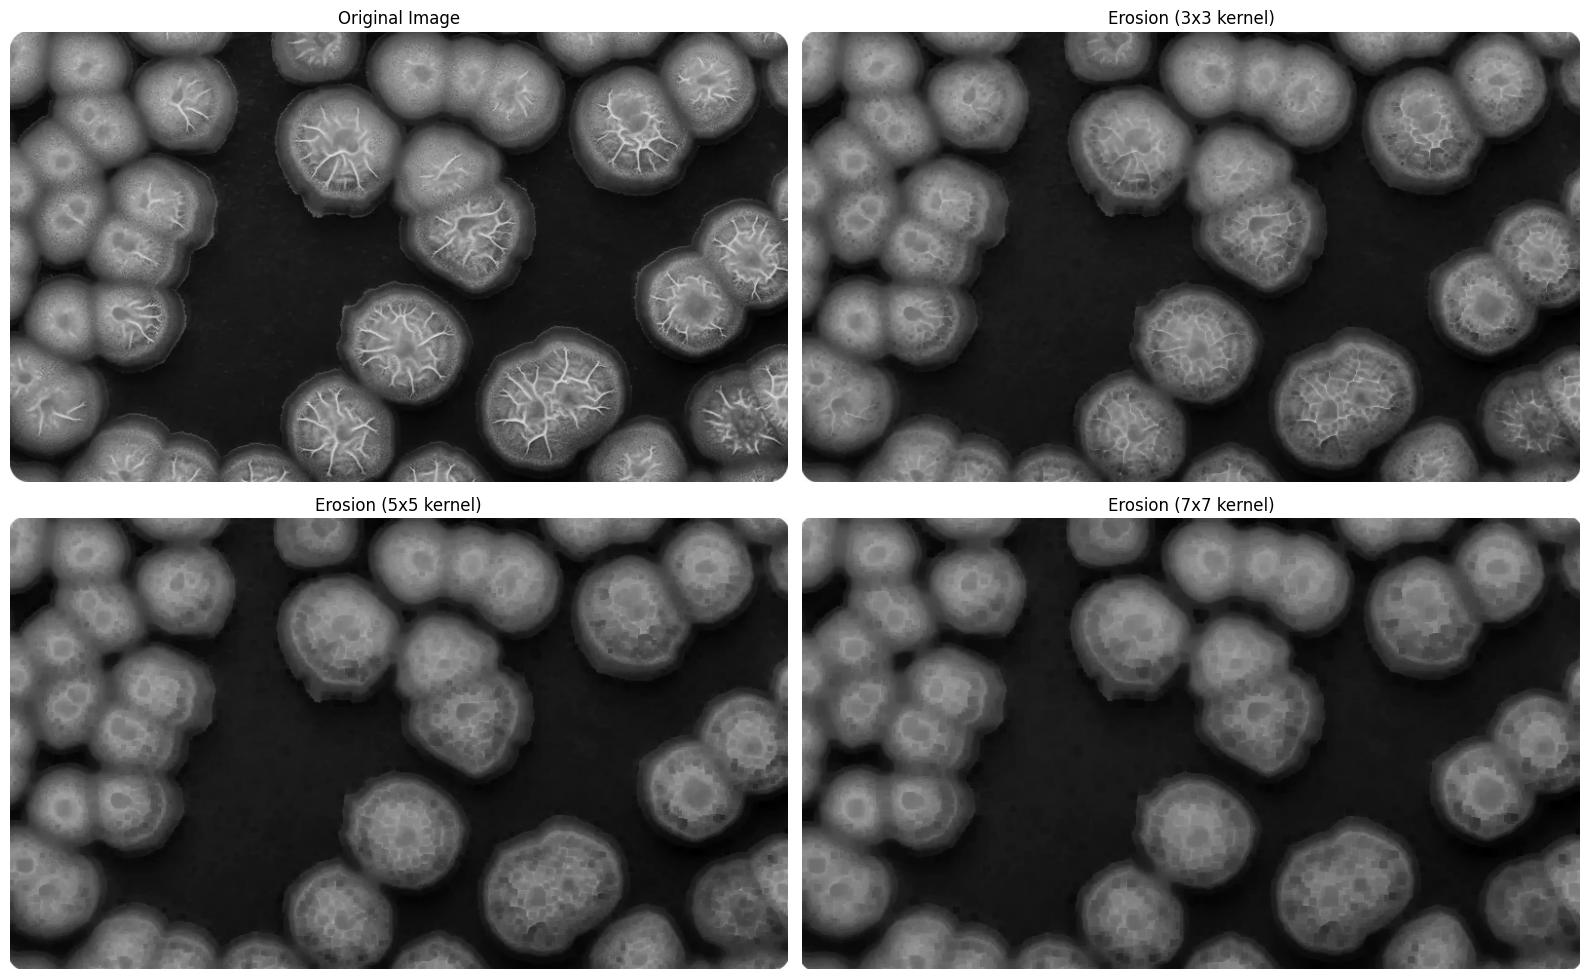

In [25]:
# Load and convert image
# https://www.ultralytics.com/blog/cell-segmentation-what-it-is-and-how-vision-ai-enhances-it
img = cv2.imread('data/cells.jpg')
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Define structuring elements
kernel_3x3 = np.ones((3, 3), dtype=np.uint8)
kernel_5x5 = np.ones((5, 5), dtype=np.uint8)
kernel_7x7 = np.ones((7, 7), dtype=np.uint8)

# Manual implementation
eroded_3x3 = erode(gray_image, kernel_3x3)
eroded_5x5 = erode(gray_image, kernel_5x5)
eroded_7x7 = erode(gray_image, kernel_7x7)

# Display manual results
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(gray_image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(eroded_3x3, cmap='gray')
axes[0, 1].set_title('Erosion (3x3 kernel)')
axes[0, 1].axis('off')

axes[1, 0].imshow(eroded_5x5, cmap='gray')
axes[1, 0].set_title('Erosion (5x5 kernel)')
axes[1, 0].axis('off')

axes[1, 1].imshow(eroded_7x7, cmap='gray')
axes[1, 1].set_title('Erosion (7x7 kernel)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

The erosion operations successfully demonstrate progressive boundary shrinking with increasing structuring element sizes. The 3x3 kernel erosion produces subtle yet effective boundary reduction, maintaining cell structure while beginning to separate touching cells. The thin connections between adjacent cells in the upper-left cluster show initial separation, demonstrating erosion's capability for breaking weak links between objects.

The 5x5 kernel erosion exhibits more pronounced shrinking effects. Cell boundaries are noticeably reduced, and previously touching cells are now clearly separated. The internal structures within cells become less prominent, and smaller cells show significant size reduction. This kernel size effectively balances separation capability with structural preservation.

The 7x7 kernel erosion demonstrates the most aggressive boundary removal. Cells are substantially smaller than the original, with some smaller cells nearly disappearing. While this strong erosion effectively separates all clustered cells, it significantly compromises size accuracy and may eliminate features important for subsequent analysis.

Key observations include the progressive nature of morphological erosion: larger kernels amplify the shrinking effect proportionally. The operation successfully achieves its primary objectives: removing small noise artifacts, breaking connections between touching objects, and thinning object boundaries. However, the results highlight the critical importance of structuring element selection. The 3x3 kernel proves optimal for this application, providing adequate cell separation while preserving morphological integrity necessary for accurate cell counting and size measurements. These findings validate erosion as an effective preprocessing technique for medical image analysis, particularly in automated cell segmentation pipelines.

## 2 - Morphological Dilation in Image Processing

**Research Background**

Morphological dilation is a fundamental operation in mathematical morphology that expands or thickens objects in digital images. As the dual operation to erosion, dilation plays a crucial role in various image processing applications including noise filling, object connection, and feature enhancement (Gonzalez & Woods, 2018). Dilation operates by expanding foreground regions using a structuring element that probes the image and grows objects where the element fits.

Dilation is a morphological operation that adds pixels to object boundaries based on the structuring element's interaction with the image (Soille, 2003). Mathematically, dilation of image A by structuring element B is defined as the set of all points where B, when translated, overlaps with at least one foreground pixel in A. For grayscale images, dilation replaces each pixel with the maximum value within the neighborhood defined by the structuring element, brightening images and filling small holes or gaps (Burger & Burge, 2016).

**Application: Text Enhancement and Gap Filling**

Dilation finds significant application in document image processing and optical character recognition (OCR) systems. When scanned documents contain broken characters due to poor quality, low contrast, or degradation, dilation can reconnect fragmented strokes and fill small gaps, improving text readability and recognition accuracy (Gonzalez & Woods, 2018). This operation is also valuable in preprocessing steps for license plate recognition, where environmental factors may cause character breaks or discontinuities that hinder automated reading systems.

**References**

- Burger, W., & Burge, M. J. (2016). Digital image processing: An algorithmic introduction using Java (2nd ed.). Springer.

- Gonzalez, R. C., & Woods, R. E. (2018). Digital image processing (4th ed.). Pearson.

- Soille, P. (2003). Morphological image analysis: Principles and applications (2nd ed.). Springer.

In [26]:
def dilate(image, kernel):
    """
    Morphological dilation operation
    Args:
        image: 2D numpy array (grayscale image)
        kernel: 2D numpy array (structuring element)
    Returns:
        Dilated image
    """
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape
    
    pad_h = ker_h // 2
    pad_w = ker_w // 2
    
    # Padding with minimum value
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), 
                    mode='constant', constant_values=0)
    
    output = np.zeros_like(image, dtype=np.float64)
    
    # Dilation: maximum value in neighborhood
    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i+ker_h, j:j+ker_w]
            output[i, j] = np.max(region[kernel == 1])
    
    return output

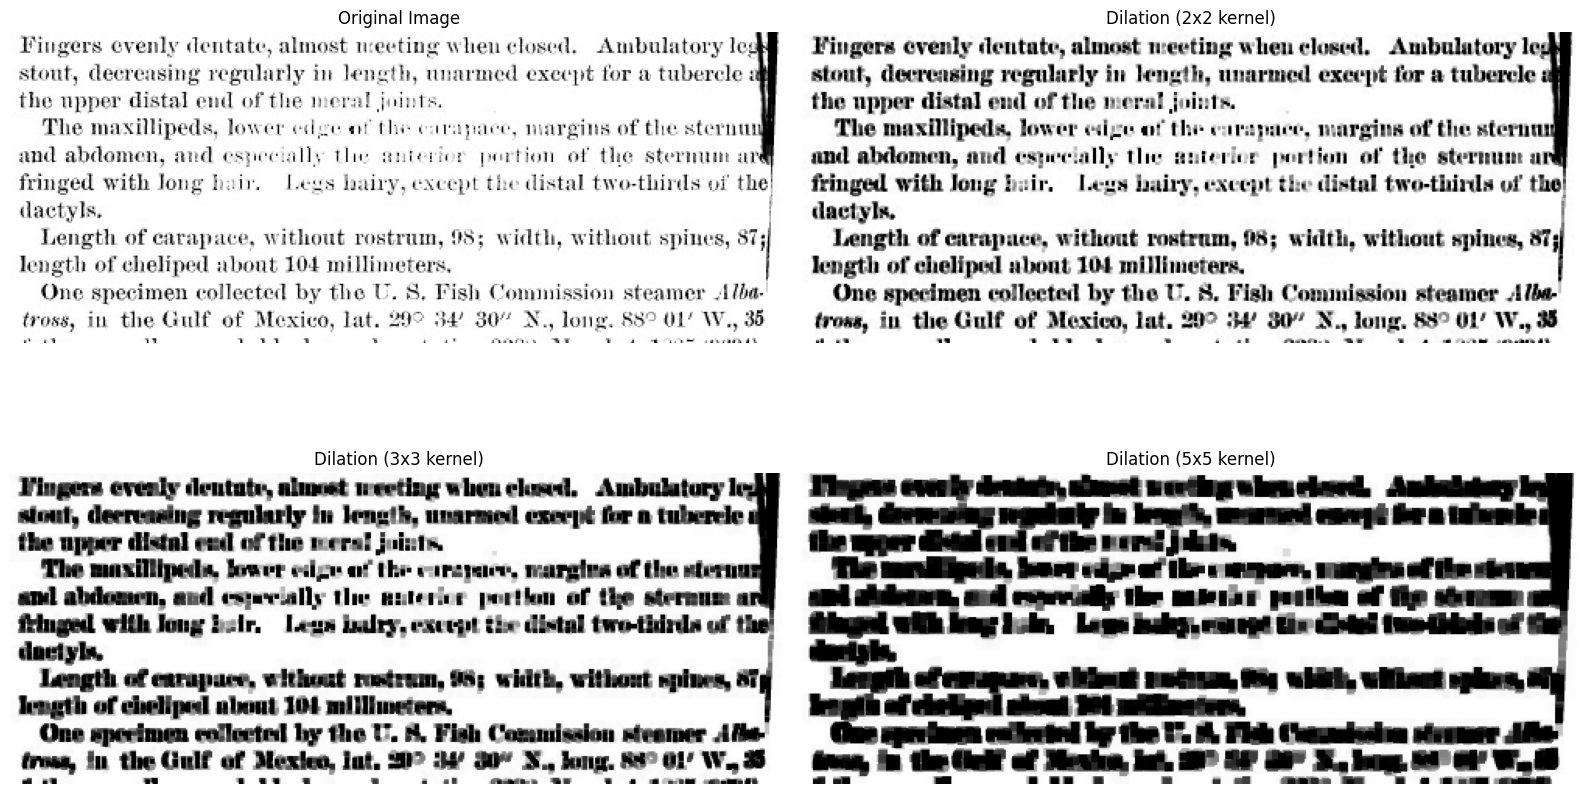

In [27]:
# Load and convert image
# https://www.google.com/url?sa=i&url=https%3A%2F%2Fresearch.nhm.org%2Fmbc%2Fprotocols%2Fscanning%2Fpdfrating.html&psig=AOvVaw37Dr9dPuwXgzgoBhTc1IzQ&ust=1759778358954000&source=images&cd=vfe&opi=89978449&ved=0CBUQjRxqFwoTCPi7tbHjjZADFQAAAAAdAAAAABAL
img = cv2.imread('data/ocr-text.jpg')
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Invert: text white, background black
inverted_image = 255 - gray_image

# Define SMALLER structuring elements for subtle progression
kernel_2x2 = np.ones((2, 2), dtype=np.uint8)
kernel_3x3 = np.ones((3, 3), dtype=np.uint8)
kernel_5x5 = np.ones((5, 5), dtype=np.uint8)

# Manual implementation on inverted image
dilated_2x2 = dilate(inverted_image, kernel_2x2)
dilated_3x3 = dilate(inverted_image, kernel_3x3)
dilated_5x5 = dilate(inverted_image, kernel_5x5)

# Invert back for display
dilated_2x2 = 255 - dilated_2x2
dilated_3x3 = 255 - dilated_3x3
dilated_5x5 = 255 - dilated_5x5

# Display manual results
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(gray_image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(dilated_2x2, cmap='gray')
axes[0, 1].set_title('Dilation (2x2 kernel)')
axes[0, 1].axis('off')

axes[1, 0].imshow(dilated_3x3, cmap='gray')
axes[1, 0].set_title('Dilation (3x3 kernel)')
axes[1, 0].axis('off')

axes[1, 1].imshow(dilated_5x5, cmap='gray')
axes[1, 1].set_title('Dilation (5x5 kernel)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

The dilation operations successfully demonstrate progressive character thickening and gap-filling capabilities across different structuring element sizes. However, a critical preprocessing step was required to achieve correct results: image inversion.

* *Image Inversion Necessity*: The original document image presents text as dark pixels (low intensity values near 0) on a bright background (high intensity values near 255). Since morphological dilation operates by computing the maximum value within each kernel neighborhood, applying dilation directly to this configuration would expand the bright background regions rather than the text itself. To correctly dilate the text characters, the image was inverted (255 - original), converting text to bright pixels and background to dark pixels. After dilation, the image was inverted again to restore the original appearance with appropriately thickened characters.

The 2x2 kernel dilation produces subtle character enhancement, filling minimal gaps while maintaining high text fidelity. Character strokes show slight thickening, and small breaks in letters begin to close. This minimal dilation is suitable when document quality is relatively good and only minor enhancement is needed.

The 3x3 kernel dilation demonstrates moderate character thickening with visible improvement in text continuity. Previously fragmented character strokes reconnect effectively, and thin or faded portions of letters gain prominence. This kernel size achieves an optimal balance between character enhancement and legibility preservation, making it particularly valuable for OCR preprocessing of degraded documents.

The 5x5 kernel dilation exhibits substantial character expansion. While effectively filling all gaps and strengthening weak characters, this aggressive dilation begins to merge adjacent characters and reduce inter-character spacing. Text remains readable but shows signs of over-processing, with some loss of fine character details.

Key findings validate dilation's effectiveness for document image enhancement. The operation successfully reconnects fragmented strokes, fills degradation-induced gaps, and strengthens faded characters. The image inversion requirement highlights the importance of understanding pixel value semantics in morphological operations. Results demonstrate that moderate dilation (3x3 kernel) provides optimal enhancement for OCR applications, while larger kernels risk character merging and detail loss. These findings confirm dilation as an essential preprocessing technique for improving automated text recognition accuracy in degraded or low-quality document images.

## 3 - Morphological Opening and Closing in Image Processing

**Research Background**

Morphological opening and closing are compound operations that combine erosion and dilation in specific sequences to achieve sophisticated image processing effects. These operations are particularly valuable because they preserve essential image features while removing noise, filling gaps, or smoothing object boundaries (Gonzalez & Woods, 2018). Unlike simple erosion or dilation, opening and closing operations maintain approximate object sizes while achieving their respective preprocessing goals.

* **Opening** consists of erosion followed by dilation using the same structuring element. This operation removes small objects, breaks thin connections between objects, and eliminates protrusions while preserving the overall shape and size of larger structures (Soille, 2003). Opening is particularly effective for noise removal in images where small bright artifacts must be eliminated without significantly altering main features.

* **Closing** consists of dilation followed by erosion. This operation fills small holes, connects nearby objects, and smooths object boundaries by filling concavities. Closing is valuable when gaps within objects need to be filled or when nearby structures should be merged (Burger & Burge, 2016).

**Application: Cell Segmentation and Analysis in Biomedical Research**

Opening and closing operations are essential in automated cell analysis systems for biomedical research and clinical diagnostics. In microscopy imaging, cells often appear with noise artifacts, touching boundaries, and internal structural irregularities that complicate automated counting and morphological analysis.

Opening is applied first to remove small noise particles and separate touching cells by erosing thin connections, then restoring approximate cell sizes through dilation. This process eliminates spurious bright spots while preserving individual cell structures (Soille, 2003). Closing addresses the opposite problem by filling small gaps within cell nuclei and smoothing irregular boundaries caused by staining inconsistencies or imaging artifacts. This operation connects fragmented regions of the same cell and produces more uniform cell shapes suitable for quantitative analysis (Gonzalez & Woods, 2018).

The sequential or combined use of these operations enables robust preprocessing pipelines that improve segmentation accuracy in automated cell counting systems, facilitating critical measurements such as cell population density, size distribution, and morphological characterization used in cancer research, drug efficacy studies, and diagnostic pathology (Burger & Burge, 2016).

**References**

- Burger, W., & Burge, M. J. (2016). *Digital image processing: An algorithmic introduction using Java* (2nd ed.). Springer.

- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4th ed.). Pearson.

- Soille, P. (2003). *Morphological image analysis: Principles and applications* (2nd ed.). Springer.

In [28]:
def morphological_opening(image, kernel):
    """
    Morphological opening (erosion followed by dilation)
    Args:
        image: 2D numpy array (grayscale image)
        kernel: 2D numpy array (structuring element)
    Returns:
        Opened image
    """
    eroded = erode(image, kernel)
    opened = dilate(eroded, kernel)
    return opened

In [29]:
def morphological_closing(image, kernel):
    """
    Morphological closing (dilation followed by erosion)
    Args:
        image: 2D numpy array (grayscale image)
        kernel: 2D numpy array (structuring element)
    Returns:
        Closed image
    """
    dilated = dilate(image, kernel)
    closed = erode(dilated, kernel)
    return closed

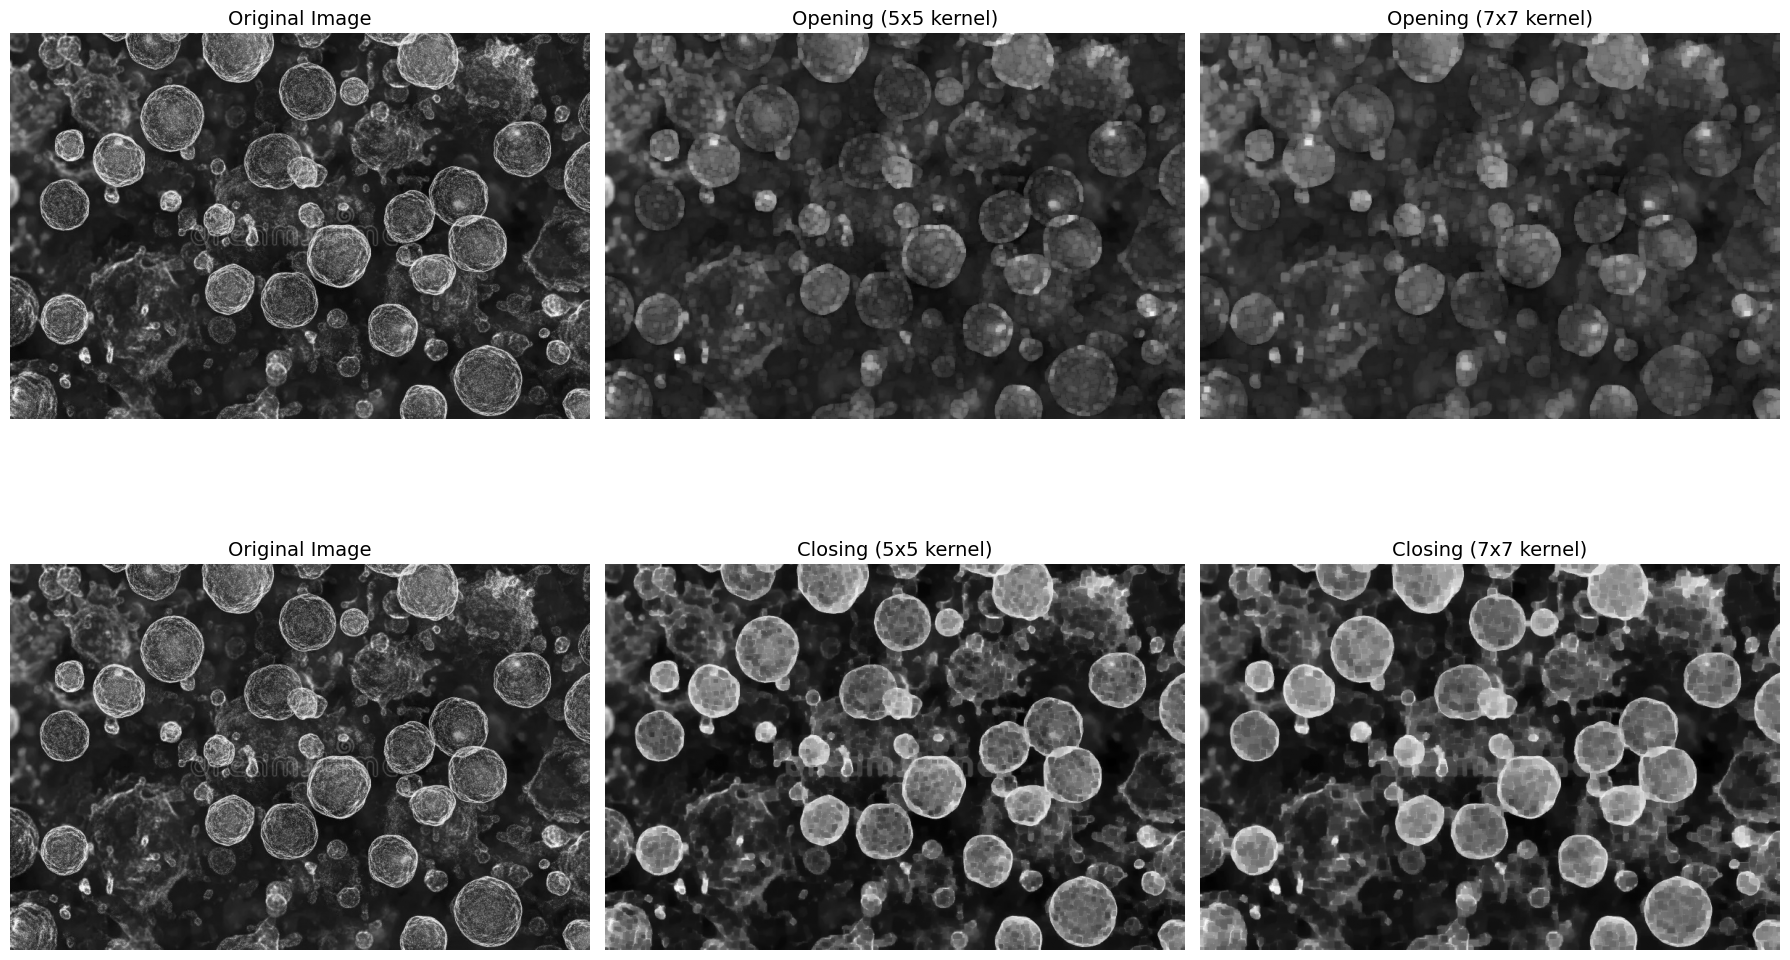

In [30]:
# Load and convert image
# https://www.dreamstime.com/close-up-cells-microscopic-view-cell-clusters-image379455040
img = cv2.imread('data/cells-2.jpg')
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Define larger structuring elements for more visible effects
kernel_5x5 = np.ones((5, 5), dtype=np.uint8)
kernel_7x7 = np.ones((7, 7), dtype=np.uint8)
kernel_9x9 = np.ones((9, 9), dtype=np.uint8)

# Manual implementation
opened_5x5 = morphological_opening(gray_image, kernel_5x5)
opened_7x7 = morphological_opening(gray_image, kernel_7x7)
closed_5x5 = morphological_closing(gray_image, kernel_5x5)
closed_7x7 = morphological_closing(gray_image, kernel_7x7)

# Display manual results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(gray_image, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=14)
axes[0, 0].axis('off')

axes[0, 1].imshow(opened_5x5, cmap='gray')
axes[0, 1].set_title('Opening (5x5 kernel)', fontsize=14)
axes[0, 1].axis('off')

axes[0, 2].imshow(opened_7x7, cmap='gray')
axes[0, 2].set_title('Opening (7x7 kernel)', fontsize=14)
axes[0, 2].axis('off')

axes[1, 0].imshow(gray_image, cmap='gray')
axes[1, 0].set_title('Original Image', fontsize=14)
axes[1, 0].axis('off')

axes[1, 1].imshow(closed_5x5, cmap='gray')
axes[1, 1].set_title('Closing (5x5 kernel)', fontsize=14)
axes[1, 1].axis('off')

axes[1, 2].imshow(closed_7x7, cmap='gray')
axes[1, 2].set_title('Closing (7x7 kernel)', fontsize=14)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

The morphological opening and closing operations successfully demonstrate their complementary preprocessing capabilities on electron microscopy imagery. The results reveal distinct characteristics and applications for each compound operation.

Opening operations effectively remove background noise and small artifacts without significantly altering the size of primary cell structures. The 5x5 kernel opening produces noticeable noise reduction, eliminating granular texture and small debris particles from the background while preserving cell boundaries. Edge irregularities on cell membranes are smoothed, and small protrusions are removed. The 7x7 kernel opening exhibits more aggressive noise elimination, producing cleaner backgrounds and more uniform cell shapes. However, this stronger effect begins to erode fine structural details and may compromise accurate size measurements of smaller cells. These results validate opening's effectiveness for eliminating false positives in automated detection systems.

Closing operations demonstrate opposite yet equally valuable effects. The 5x5 kernel closing fills small gaps within cell structures and smooths irregular boundaries, producing more homogeneous and complete cell representations. Internal texture variations are reduced, and nearby cell regions show increased connectivity. The 7x7 kernel closing exhibits substantial gap-filling and boundary smoothing effects. Cells appear more rounded and uniform, with adjacent structures beginning to merge. This aggressive closing effectively connects fragmented defect regions but risks merging distinct adjacent cells into single objects.

Comparative analysis reveals the complementary nature of these operations. Opening preserves approximate object sizes while removing noise, making it ideal for eliminating spurious detections. Closing maintains object count while filling gaps, making it valuable for consolidating fragmented structures. The choice between 5x5 and 7x7 kernels represents a trade-off between subtle enhancement and aggressive preprocessing. Moderate kernels (5x5) provide optimal balance for most applications, while larger kernels (7x7) suit images with substantial noise or severe fragmentation.

These findings confirm that sequential application of opening and closing operations creates robust preprocessing pipelines for automated quality control systems, effectively distinguishing genuine structural features from imaging artifacts and noise.